<a href="https://colab.research.google.com/github/vershita31/handwritten-digit-classification/blob/main/HandWrittenDigits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Import necessary libraries
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [24]:
#Load the handwritten digits dataset from sklearn
digits = datasets.load_digits()

In [25]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [26]:
# View the structure of the dataset
print(f"Data shape: {digits.data.shape}")

Data shape: (1797, 64)


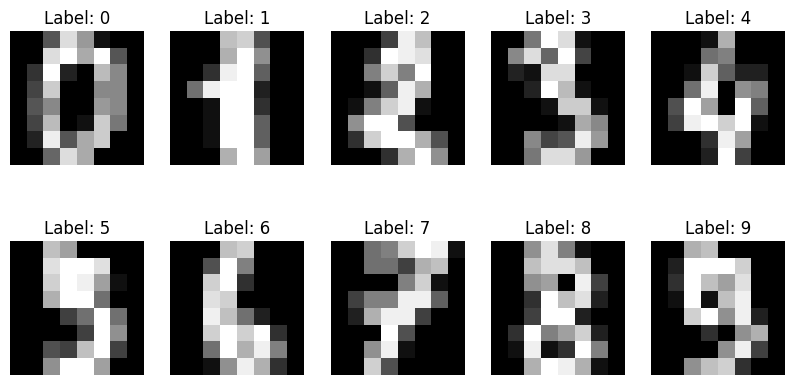

In [27]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.show()

In [28]:
print(f"Target shape: {digits.target.shape}")

Target shape: (1797,)


In [29]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42)


In [30]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)

In [31]:
# Train the model
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
# Make predictions
y_pred = logreg.predict(X_test)

In [33]:
# Evaluate the model



accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.85%


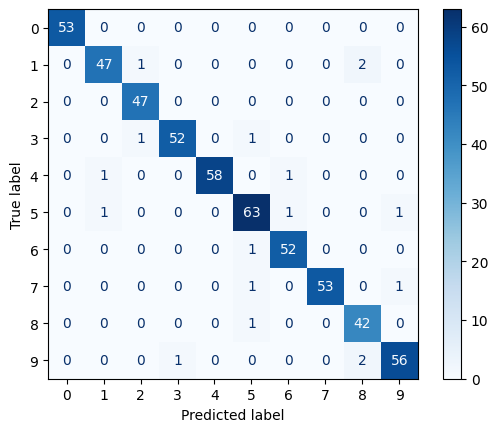

In [34]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

In [35]:
#classification
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.94      0.95        50
           2       0.96      1.00      0.98        47
           3       0.98      0.96      0.97        54
           4       1.00      0.97      0.98        60
           5       0.94      0.95      0.95        66
           6       0.96      0.98      0.97        53
           7       1.00      0.96      0.98        55
           8       0.91      0.98      0.94        43
           9       0.97      0.95      0.96        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



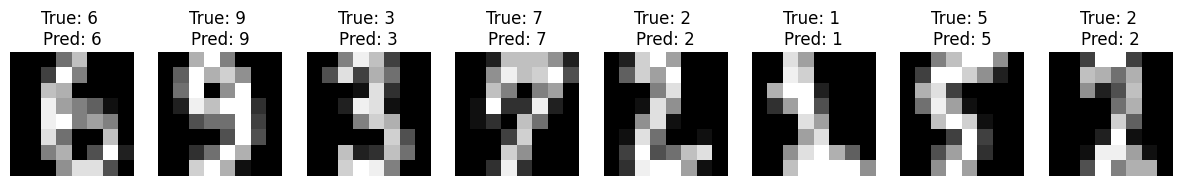

In [36]:
# Visualization of some test images with their predicted and true labels
n_images = 8  # Number of images to display new
fig, axes = plt.subplots(1, n_images, figsize=(15, 5))

# Loop through the images
for i in range(n_images):
    ax = axes[i]
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')  # Reshape to 8x8 image
    ax.set_title(f"True: {y_test[i]} \nPred: {y_pred[i]}")  # Show true and predicted labels
    ax.axis('off')

plt.show()

In [37]:
#Compare with another model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9925925925925926


KNN Accuracy = 0.9926 ≈ 99.26%
That means **out of 100 predictions**, about **99 are correct**.
This high accuracy is expected because the digits dataset is small, clean, and contains well-separated handwritten digit patterns.

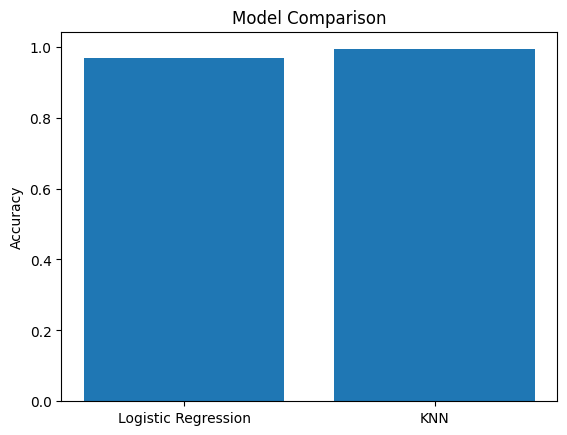

In [38]:
#Accuracy Comparison
models = ["Logistic Regression", "KNN"]
scores = [accuracy_score(y_test, y_pred),
          accuracy_score(y_test, knn_pred)]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()